In [1]:
#Part A - Data preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Data loading
fear = pd.read_csv(r"C:\Users\srika\OneDrive\Desktop\trader-sentiment-analysis\data\fear_greed_index.csv")
historical = pd.read_csv(r"C:\Users\srika\OneDrive\Desktop\trader-sentiment-analysis\data\historical_data.csv")

In [7]:
# Data set Info
print(fear.shape)
print(historical.shape)

print(fear.info())
print(historical.info())

(2644, 4)
(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Sta

In [9]:
# Missing values checking
fear.isnull().sum()
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
# Duplicates checking
fear.duplicated().sum()
historical.duplicated().sum()

np.int64(0)

In [14]:
fear.head(5)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [15]:
historical.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [18]:
historical['Timestamp'] = pd.to_datetime(traders['Timestamp'], errors='coerce')

In [19]:
historical['date'] = historical['Timestamp'].dt.date

In [20]:
historical[['Timestamp','date']].head()

,Timestamp,date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [22]:
fear['date'] = pd.to_datetime(fear['date'])
fear['date'] = fear['date'].dt.date

In [23]:
fear['date'].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [34]:
# Combining both tables
merged = pd.merge(historical, fear[['date','classification','value']], 
                  on='date', 
                  how='left')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN


In [29]:
print(merged.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [36]:
# Creation of Key Metrics
# 1.Daily PnL per Trader -- It shows how much profit each trader makes per day.

daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,1.686580e+05


In [37]:
# 2.Total PnL by Sentiment Fear vs Greed
pnl_sentiment = merged.groupby('classification')['Closed PnL'].sum()
print(pnl_sentiment)

out put :Series([], Name: Closed PnL, dtype: float64)


Series([], Name: Closed PnL, dtype: float64)


In [38]:
merged.shape

(211224, 19)

In [39]:
merged['classification'].unique()

array([nan], dtype=object)

In [43]:
fear['date'].head()


0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [44]:
historical['date'].head()

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object

In [45]:
fear['date'] = pd.to_datetime(fear['date']).dt.date
historical['date'] = pd.to_datetime(historical['Timestamp']).dt.date

In [47]:
merged = pd.merge(historical, fear[['date','classification','value']], 
                  on='date', 
                  how='left')

In [48]:
# 2.Total PnL by Sentiment Fear vs Greed
pnl_sentiment = merged.groupby('classification')['Closed PnL'].sum()
print(pnl_sentiment)

Series([], Name: Closed PnL, dtype: float64)


In [49]:
merged[['date','classification']].head()

,date,classification
0,1970-01-01,NaN
1,1970-01-01,NaN
2,1970-01-01,NaN
3,1970-01-01,NaN
4,1970-01-01,NaN


In [51]:
historical['Timestamp'].head()

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [53]:
historical['Timestamp IST'].head()

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [55]:
historical['Timestamp'] = pd.to_datetime(
    historical['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

historical['Timestamp'].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp, dtype: datetime64[ns]

In [58]:
historical['date'] = historical['Timestamp'].dt.date

historical[['Timestamp','date']].head()

,Timestamp,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [60]:
fear['date'] = pd.to_datetime(fear['date']).dt.date
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [61]:
merged = pd.merge(
    historical,
    fear[['date','classification','value']],
    on='date',
    how='left'
)

In [62]:
merged[['date','classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [63]:
# 2.Total PnL by Sentiment Fear vs Greed
pnl_sentiment = merged.groupby('classification')['Closed PnL'].sum()
print(pnl_sentiment)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [65]:
# 3. Average trade size
avg_trade_size = merged['Size USD'].mean()

print("Average Trade Size:", avg_trade_size)

Average Trade Size: 5639.451210373822


In [66]:
# 4. Number of trades per day
trades_per_day = merged.groupby('date')['Trade ID'].count().reset_index(name='trade_count')

trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [67]:
# 5.Win rate
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged['win'].mean()

print("Win Rate:", win_rate)

Win Rate: 0.4112648183918494


In [68]:
# 6 . Win rate by sentimen
win_rate_sentiment = merged.groupby('classification')['win'].mean()

print(win_rate_sentiment)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [69]:
# 7 .Average Pnl per trade
avg_pnl = merged['Closed PnL'].mean()

print("Average PnL:", avg_pnl)

Average PnL: 48.74900079269401


In [70]:
# 9. Total trade value
volume = merged['Size USD'].sum()

print("Total Trading Volume:", volume)

Total Trading Volume: 1191187442.46


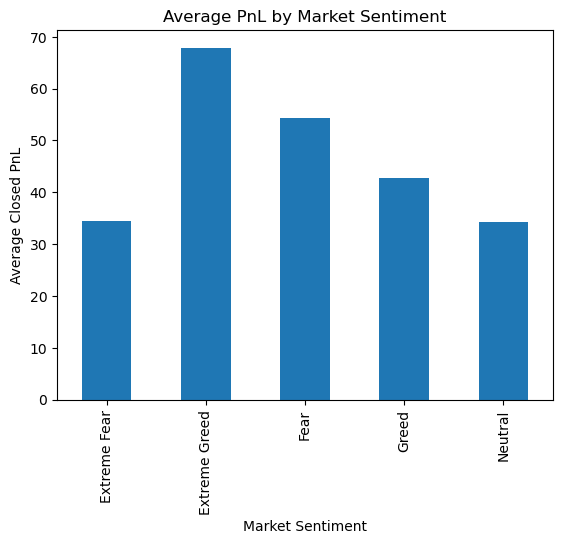

In [73]:
# Part B — Analysis

#1.Average Pnl by Market Sentiment

sentiment_pnl = merged.groupby('classification')['Closed PnL'].mean()

sentiment_pnl.plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Text(0.5, 1.0, 'Trading Frequency by Sentiment')

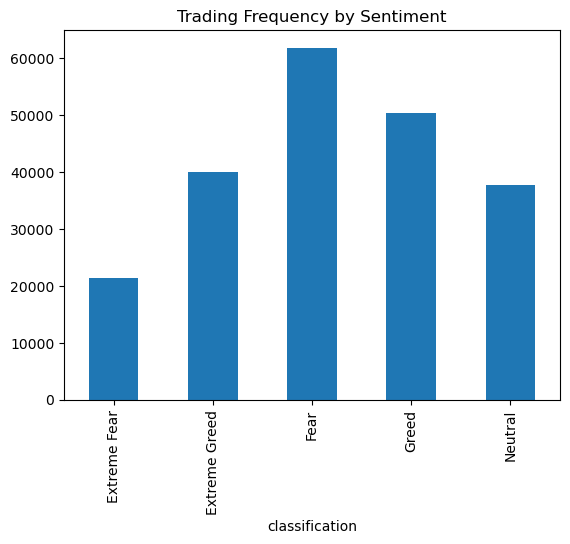

In [75]:
# 2.Trading Frequency by Sentiment

trade_freq = merged.groupby('lassification').size()

trade_freq.plot(kind='bar')
plt.title("Trading Frequency by Sentiment")

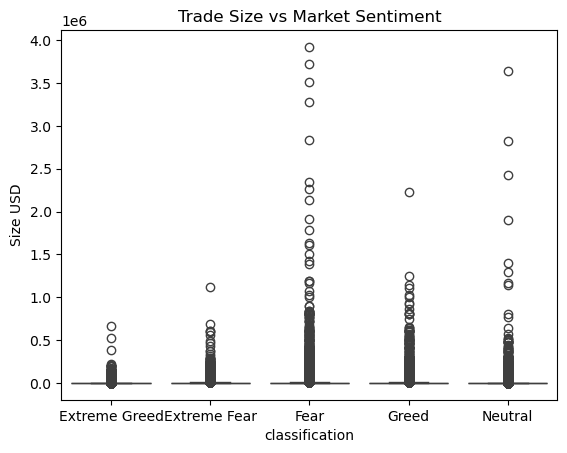

In [78]:
# 3. Trade Size By Market Sentiment
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size By Market Sentiment")
plt.show()

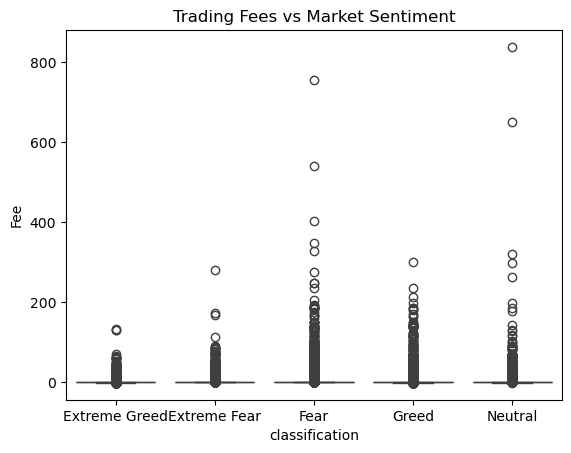

In [79]:
sns.boxplot(x='classification', y='Fee', data=merged)
plt.title("Trading Fees vs Market Sentiment")
plt.show()

In [84]:
# Creation of leverage Column
merged['leverage_est'] = merged['Size USD'] / merged['Execution Price']
merged[['Size USD','Execution Price','leverage_est']].head()

,Size USD,Execution Price,leverage_est
0,7872.16,7.9769,986.869586
1,127.68,7.9800,16.000000
2,1150.63,7.9855,144.089913
3,1142.04,7.9874,142.980194
4,69.75,7.9894,8.730318


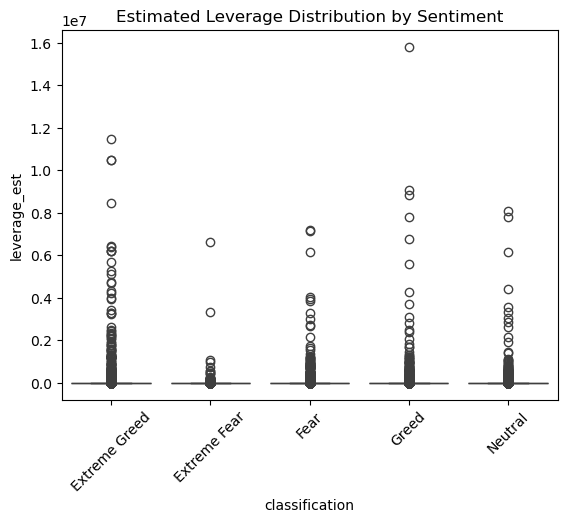

In [85]:
# 4.Leverage Distribution by Sentiment
sns.boxplot(x='classification', y='leverage_est', data=merged)

plt.title("Estimated Leverage Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [87]:
# Table for long and short
long_short = merged.groupby(['classification','Side']).size().reset_index(name='count')

long_short.head()

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270


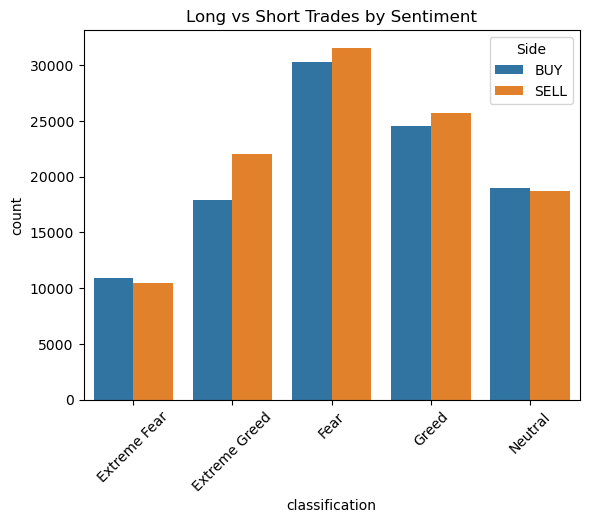

In [88]:
# 5.Long vs Short Trades by Sentiment

sns.barplot(x='classification', y='count', hue='Side', data=long_short)

plt.title("Long vs Short Trades by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [89]:
trader_perf = merged.groupby('Account')['Closed PnL'].sum().reset_index()

trader_perf['segment'] = pd.qcut(trader_perf['Closed PnL'],4,
                                labels=['Low','Medium','High','Top'])

trader_perf.head()

,Account,Closed PnL,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Top
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Medium
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Low
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,High
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,High


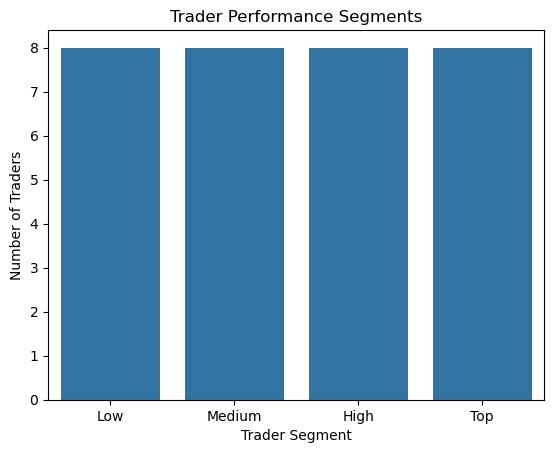

In [90]:
# 6.Trader Performance Segments
sns.countplot(x='segment', data=trader_perf)

plt.title("Trader Performance Segments")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")

plt.show()

In [91]:
sentiment_pnl = merged.groupby('classification')['Closed PnL'].mean().reset_index()

sentiment_pnl

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718
